<a href="https://colab.research.google.com/github/jilliangreene/sta_554_assignments/blob/main/Greene_STA554_HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STA 554 HW 6
Jillian Greene


## Part 1

1. Connect to the database and then look at all of the tables in the database (use `read_sql()` from
`pandas` to have this returned as a data frame). (2 pts)

In [ ]:
import pandas as pd
import sqlite3

con = sqlite3.connect('lahman_1871-2022.sqlite')

# Look at all tables in database using pd.read_sql()
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", con)
print(tables)

                   name
0           AllstarFull
1           Appearances
2        AwardsManagers
3         AwardsPlayers
4   AwardsShareManagers
5    AwardsSharePlayers
6               Batting
7           BattingPost
8        CollegePlaying
9              Fielding
10           FieldingOF
11      FieldingOFsplit
12         FieldingPost
13           HallOfFame
14            HomeGames
15             Managers
16         ManagersHalf
17                Parks
18               People
19             Pitching
20         PitchingPost
21             Salaries
22              Schools
23           SeriesPost
24                Teams
25      TeamsFranchises
26            TeamsHalf


2. Using SQL, construct a table of hall of fame pitchers (any hall of famer that pitched) that gives the
`playerID` and their total (sum) for `GS`, `G`, `W`, `L`, `IPOuts`, `CG`, `SHO`, and `SV` columns. The summing can
be done in pandas or in the SQL call. (6 pts)

In [ ]:
# Query for HallOfFame players that were pitchers
query = "SELECT Pitching.playerID, Pitching.GS, Pitching.G, Pitching.W, Pitching.L, Pitching.IPOuts, Pitching.CG, Pitching.SHO, Pitching.SV FROM Pitching INNER JOIN HallOfFame ON Pitching.playerID = HallOfFame.playerID WHERE inducted = 'Y';"
hof_pitchers = pd.read_sql(query, con)
hof_pitchers = hof_pitchers.groupby('playerID').sum()
hof_pitchers

,GS,G,W,L,IPouts,CG,SHO,SV
playerID,,,,,,,,
alexape01,599,696,373,208,15570,437,90,32
ansonca01,0,3,0,1,12,0,0,1
becklja01,1,1,0,1,12,0,0,0
bendech01,334,459,212,127,9051,255,40,34
blylebe01,685,692,287,250,14910,242,60,0
...,...,...,...,...,...,...,...,...
willivi01,471,513,249,205,11988,388,50,11
wrighge01,0,3,0,1,15,0,0,0
wrighha01,8,36,4,4,301,0,0,14


3. For all of the hall of fame pitchers, use SQL to create a table of their batting statistics. Namely, the
`playerID` and their total (sum) for `AB`, `R`, `H`, `HR`, `RBI`, `BB`, and `SO`. The summing can be done in `pandas`
or in the SQL call. (4 pts)

In [ ]:
query = """
SELECT
    Batting.playerID,
    Batting.AB,
    Batting.R,
    Batting.H,
    Batting.HR,
    Batting.RBI,
    Batting.BB,
    Batting.SO
FROM Batting
INNER JOIN HallOfFame
    ON Batting.playerID = HallOfFame.playerID
INNER JOIN Pitching
    ON Batting.playerID = Pitching.playerID
WHERE HallOfFame.inducted = 'Y';
"""
hof_pitchers_batting_stats = pd.read_sql(query, con)
hof_pitchers_batting_stats = hof_pitchers_batting_stats.groupby('playerID').sum()
hof_pitchers_batting_stats

,AB,R,H,HR,RBI,BB,SO
playerID,,,,,,,
alexape01,38010,3234,7938,231,3423.0,1617,5796.0
ansonca01,20562,3998,6870,194,4150.0,1968,660.0
becklja01,9551,1603,2938,87,1581.0,616,526.0
bendech01,18352,1632,3888,96,1856.0,1200,2288.0
blylebe01,10824,456,1416,0,600.0,120,4632.0
...,...,...,...,...,...,...,...
willivi01,19409,1391,3224,13,1092.0,1053,2587.0
wrighge01,5746,1330,1732,22,652.0,136,238.0
wrighha01,3252,732,896,16,452.0,148,56.0


4. Using `pandas` join the previous two tables together by `pitcher`. (If you want, try to do all of this via
SQL! Not required though, feel free to use `pd.merge()` if you’d like) (4 pts)

In [ ]:
merged_table = pd.merge(hof_pitchers, hof_pitchers_batting_stats, on='playerID')
merged_table

,GS,G,W,L,IPouts,CG,SHO,SV,AB,R,H,HR,RBI,BB,SO
playerID,,,,,,,,,,,,,,,
alexape01,599,696,373,208,15570,437,90,32,38010,3234,7938,231,3423.0,1617,5796.0
ansonca01,0,3,0,1,12,0,0,1,20562,3998,6870,194,4150.0,1968,660.0
becklja01,1,1,0,1,12,0,0,0,9551,1603,2938,87,1581.0,616,526.0
bendech01,334,459,212,127,9051,255,40,34,18352,1632,3888,96,1856.0,1200,2288.0
blylebe01,685,692,287,250,14910,242,60,0,10824,456,1416,0,600.0,120,4632.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
willivi01,471,513,249,205,11988,388,50,11,19409,1391,3224,13,1092.0,1053,2587.0
wrighge01,0,3,0,1,15,0,0,0,5746,1330,1732,22,652.0,136,238.0
wrighha01,8,36,4,4,301,0,0,14,3252,732,896,16,452.0,148,56.0


## Part 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from numpy.random import default_rng

1. Create a `class` that encapsulates the simulation of the sampling distribution and slope estimator

In [8]:
class SLR_slope_simulator:
  # Initialize the class with arguments self, beta_0, beta_1, sigma, x, n, and seed
  def __init__(self, beta_0, beta_1, x, sigma, seed):
    self.beta_0 = beta_0
    self.beta_1 = beta_1
    self.sigma = sigma
    self.x = x
    self.n = len(x)
    self.rng = np.random.default_rng(seed)
    self.slopes = []

  # Create generate_data method
  def generate_data(self):
    y = self.beta_0 + self.beta_1 * self.x + self.rng.normal(0, self.sigma, self.n)
    return self.x, y

  # Create fit_slope method
  def fit_slope(self, x, y):
    reg = linear_model.LinearRegression()
    fit = reg.fit(x.reshape(-1, 1), y)
    return fit.coef_[0]

  # Create run_sim method
  def run_sim(self, n_reps):

      slopes = []

      for i in range(n_reps):
          x, y = self.generate_data()
          slope = self.fit_slope(x, y)
          slopes.append(slope)

      self.slopes = np.array(slopes)

  # Create plot_dist method
  def plot_dist(self):

    if len(self.slopes) == 0:
        print("Error! run_simulations() must be called first")
        return

    plt.hist(self.slopes, bins=20)
    plt.xlabel('Slope')
    plt.ylabel('Frequency')
    plt.title('Distribution of Slopes')
    plt.show()

  # Create find_prob method
  def find_prob(self, value, sided):

    if len(self.slopes) == 0:
        print("Error! run_simulations() must be called first")
        return

    if sided == "above":
        prob = np.mean(self.slopes > value)

    elif sided == "below":
        prob = np.mean(self.slopes < value)

    elif sided == "two-sided":
        prob = np.mean(np.abs(self.slopes) > abs(value))

    else:
        print("Invalid sided argument")
        return

    return prob




 Below you definition of your class and its methods, add a section of code that

1. Creates an instance of the object with `beta_0` = 12, `beta_1` = 2, `x` = `np.array(list(np.linspace(start
= 0, stop = 10, num = 11))*3)`, `sigma` = 1, and `seed` = 10
2. Call your `run_simulation()` method (this should return the error message)
3. Run 10000 simulations
4. Plot the sampling distribution
5. Approximate the two-sided probability of being larger than 2.1
6. Print out the value of the simulated slopes using the attribute

In [9]:
# Create instance of the class object
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)

sim = SLR_slope_simulator(12, 2, x, 1, 10)

In [10]:
sim.plot_dist()

Error! run_simulations() must be called first


In [11]:
sim.run_sim(10000)

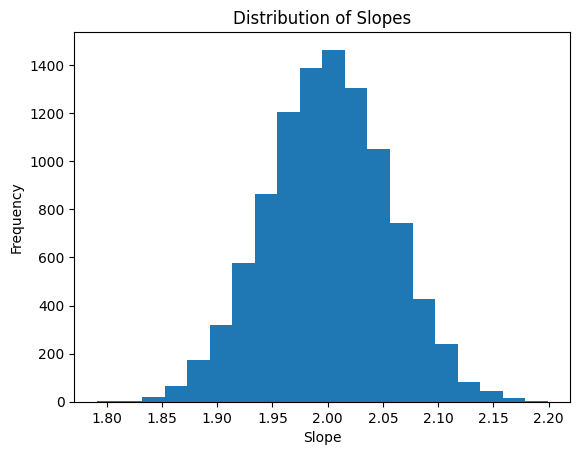

In [12]:
sim.plot_dist()

In [13]:
prob = sim.find_prob(2.1, "two-sided")
print(prob)

0.0352


In [14]:
print(sim.slopes)

[2.0239168  1.99560551 2.04249093 ... 1.93451109 2.01445559 2.07173587]
